In [1]:
import numpy as np
import pandas as pd

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = r"C:\Users\sudee\OneDrive\Documents\GitHub\Mood-Based-Music-recommendation-system\FER-2013\train"
test_dir = r"C:\Users\sudee\OneDrive\Documents\GitHub\Mood-Based-Music-recommendation-system\FER-2013\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical'
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical'
)


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\sudee\\OneDrive\\Documents\\GitHub\\Mood-Based-Music-recommendation-system\\FER-2013\\train'

In [ ]:
import numpy as np
from collections import Counter

print("Class indices:", train_gen.class_indices)
print("Total training samples:", train_gen.samples)
print("Training class distribution:")
print(Counter(train_gen.classes))


Class indices: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3}
Total training samples: 21005
Training class distribution:
Counter({1: 7215, 2: 4965, 3: 4830, 0: 3995})


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_dir = r"C:\Users\sudee\OneDrive\Documents\GitHub\Mood-Based-Music-recommendation-system\FER-2013\train"
test_dir = r"C:\Users\sudee\OneDrive\Documents\GitHub\Mood-Based-Music-recommendation-system\FER-2013\test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical',
    classes=['angry', 'happy', 'neutral', 'sad']  # ✅ explicitly specify order
)

test_gen = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48, 48),
    batch_size=32,
    class_mode='categorical',
    classes=['angry', 'happy', 'neutral', 'sad']
)


Found 21005 images belonging to 4 classes.
Found 5212 images belonging to 4 classes.


In [ ]:
print("Class indices:", train_gen.class_indices)


Class indices: {'angry': 0, 'happy': 1, 'neutral': 2, 'sad': 3}


In [ ]:
from collections import Counter

print("Training distribution:", Counter(train_gen.classes))


Training distribution: Counter({1: 7215, 2: 4965, 3: 4830, 0: 3995})


In [ ]:
from sklearn.utils import class_weight
import numpy as np

# compute balanced weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: 1.3144555694618272, 1: 0.7278239778239778, 2: 1.0576535750251763, 3: 1.0872153209109732}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


c:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,444 (1.36 MB)

 Trainable params: 356,740 (1.36 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max')
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Paths to your data folders
train_dir = r'C:\Users\sudee\OneDrive\Documents\GitHub\Mood-Based-Music-recommendation-system\FER-2013\train'
val_dir = r'C:\Users\sudee\OneDrive\Documents\GitHub\Mood-Based-Music-recommendation-system\FER-2013\test'

# Data augmentation for training
train_datagen = ImageDataGenerator(
      rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.5, 1.5],
    shear_range=0.2,
    fill_mode='nearest'
)

# Only rescale for validation
val_datagen = ImageDataGenerator(rescale=1./255)

# Generate batches of images
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='rgb',
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_directory(
    val_dir,
    target_size=(48, 48),
    batch_size=64,
    color_mode='rgb',
    class_mode='categorical'
)


Found 21005 images belonging to 4 classes.
Found 5212 images belonging to 4 classes.


In [ ]:
MODEL_PATH='cnn_model.h5'
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    MODEL_PATH, monitor='val_accuracy',
    save_best_only=True, mode='max', verbose=1
)
early_stop = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1
)


In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau

optimizer = Adam(learning_rate=1e-4)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=3,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)


In [ ]:
import os
from tensorflow.keras.models import load_model


if os.path.exists(MODEL_PATH):
    print("✅ Pre-trained model found. Loading it...")
    model = load_model(MODEL_PATH)
else:
    print("🚀 No saved model found. Starting training from scratch...")
    
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=30,
        class_weight=class_weights,
        callbacks=[checkpoint, early_stop, reduce_lr]
    )
    
    # Save final trained model
    model.save(MODEL_PATH)
    print("✅ Training complete and model saved!")

✅ Pre-trained model found. Loading it...


In [ ]:
from tensorflow.keras.models import load_model
model = load_model("cnn_model.h5")


In [ ]:
val_loss, val_acc = model.evaluate(val_gen)
print(f"✅ Validation Accuracy: {val_acc*100:.2f}%")
print(f"📉 Validation Loss: {val_loss:.4f}")


c:\Users\sudee\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6301 - loss: 0.8901
✅ Validation Accuracy: 62.09%
📉 Validation Loss: 0.8974


82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step
              precision    recall  f1-score   support

       angry       0.18      0.26      0.21       958
       happy       0.34      0.34      0.34      1774
     neutral       0.22      0.28      0.25      1233
         sad       0.23      0.10      0.14      1247

    accuracy                           0.25      5212
   macro avg       0.25      0.25      0.24      5212
weighted avg       0.26      0.25      0.25      5212



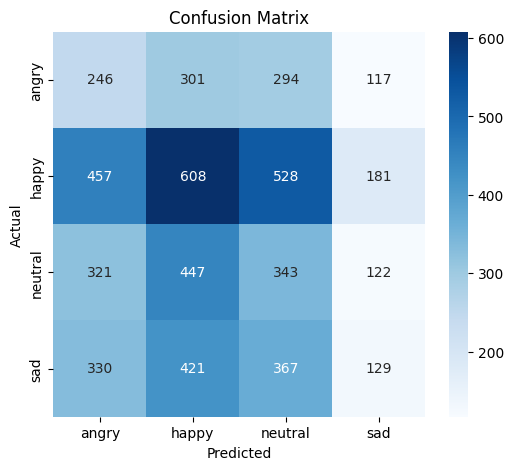

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(val_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_gen.classes
class_labels = list(val_gen.class_indices.keys())

# Classification Report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load trained model
model = load_model("cnn_model.h5")

# Emotion labels — must match your training order
emotion_labels = ['angry', 'happy', 'sad', 'neutral']

# Load image
img_path = r"C:\Users\sudee\OneDrive\Documents\GitHub\Mood-Based-Music-recommendation-system\FER-2013\test\angry\PrivateTest_1054527.jpg"   # change this to your image path
img = cv2.imread(img_path)

if img is None:
    print("❌ Could not load image! Check the path.")
    exit()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Face detector
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
faces = face_cascade.detectMultiScale(gray, 1.3, 5)

if len(faces) == 0:
    print("😐 No faces detected in the image.")
else:
    print(f"✅ Detected {len(faces)} face(s)")

for (x, y, w, h) in faces:
    roi_color = img[y:y+h, x:x+w]
    roi_resized = cv2.resize(roi_color, (48, 48))
    roi_normalized = roi_resized / 255.0
    roi_reshaped = np.expand_dims(roi_normalized, axis=0)

    preds = model.predict(roi_reshaped)
    emotion_idx = np.argmax(preds)
    emotion = emotion_labels[emotion_idx]
    confidence = np.max(preds)

    print(f"Detected Emotion: {emotion} ({confidence*100:.2f}% confidence)")

    cv2.rectangle(img, (x, y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(img, f"{emotion} ({confidence*100:.1f}%)", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

# Resize window to fit your screen better
cv2.namedWindow("Result", cv2.WINDOW_NORMAL)
cv2.resizeWindow("Result", 800, 600)

cv2.imshow("Result", img)
cv2.waitKey(0)
cv2.destroyAllWindows()


😐 No faces detected in the image.


In [ ]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import mediapipe as mp

# Load your trained model
model = load_model("cnn_model.h5")

# Define emotion labels (must match training order)
emotion_labels = ['angry', 'happy', 'sad', 'neutral']

# Initialize MediaPipe face detection
mp_face_detection = mp.solutions.face_detection
mp_drawing = mp.solutions.drawing_utils
face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.3)

# Start webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("❌ Could not open webcam.")
    exit()

print("🎥 Press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Failed to capture frame.")
        break

    # Convert frame to RGB for MediaPipe
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_detection.process(rgb_frame)

    if results.detections:
        for detection in results.detections:
            bboxC = detection.location_data.relative_bounding_box
            h, w, _ = frame.shape
            x, y, width, height = int(bboxC.xmin * w), int(bboxC.ymin * h), int(bboxC.width * w), int(bboxC.height * h)

            # Crop and preprocess face
            face = frame[y:y+height, x:x+width]
            if face.size == 0:
                continue  # skip empty crops

            face_resized = cv2.resize(face, (48, 48))
            face_normalized = face_resized / 255.0
            face_input = np.expand_dims(face_normalized, axis=0)

            # Predict emotion
            preds = model.predict(face_input, verbose=0)
            emotion = emotion_labels[np.argmax(preds)]
            confidence = np.max(preds)

            # Draw on frame
            cv2.rectangle(frame, (x, y), (x+width, y+height), (0, 255, 0), 2)
            cv2.putText(frame, f"{emotion} ({confidence*100:.1f}%)", (x, y-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

    # Show frame
    cv2.imshow("Real-Time Emotion Detection", frame)

    # Exit on 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()
face_detection.close()


🎥 Press 'q' to quit.


In [1]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model
import mediapipe as mp

# Load trained model
model = load_model("cnn_model2.h5")
emotion_labels = ['angry', 'happy', 'sad', 'neutral']

# Initialize MediaPipe face detection
mp_face_detection = mp.solutions.face_detection
face_detection = mp_face_detection.FaceDetection(model_selection=0, min_detection_confidence=0.3)

# Start webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("❌ Could not open webcam.")
    exit()

print("🎥 Press SPACE to capture an image. Press Q to quit without capturing.")

captured_frame = None

while True:
    ret, frame = cap.read()
    if not ret:
        print("❌ Failed to capture frame.")
        break

    cv2.imshow("Press SPACE to Capture", frame)

    key = cv2.waitKey(1) & 0xFF
    if key == ord(' '):  # SPACE key
        captured_frame = frame.copy()
        print("📸 Image captured!")
        break
    elif key == ord('q'):  # quit
        print("👋 Exiting without capture.")
        cap.release()
        cv2.destroyAllWindows()
        exit()

cap.release()
cv2.destroyAllWindows()

# Process captured frame
if captured_frame is not None:
    rgb_frame = cv2.cvtColor(captured_frame, cv2.COLOR_BGR2RGB)
    results = face_detection.process(rgb_frame)

    if not results.detections:
        print("😐 No faces detected.")
    else:
        h, w, _ = captured_frame.shape
        for detection in results.detections:
            bbox = detection.location_data.relative_bounding_box
            x, y, width, height = int(bbox.xmin * w), int(bbox.ymin * h), int(bbox.width * w), int(bbox.height * h)

            face = captured_frame[y:y+height, x:x+width]
            if face.size == 0:
                continue

            face_resized = cv2.resize(face, (48, 48))
            face_normalized = face_resized / 255.0
            face_input = np.expand_dims(face_normalized, axis=0)

            preds = model.predict(face_input, verbose=0)
            emotion = emotion_labels[np.argmax(preds)]
            confidence = np.max(preds)

            print(f"🧠 Detected Emotion: {emotion} ({confidence*100:.2f}% confidence)")

            # Draw bounding box and label
            cv2.rectangle(captured_frame, (x, y), (x+width, y+height), (0, 255, 0), 2)
            cv2.putText(captured_frame, f"{emotion} ({confidence*100:.1f}%)", 
                        (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)

        # Show final image
        cv2.namedWindow("Final Result", cv2.WINDOW_NORMAL)
        cv2.resizeWindow("Final Result", 900, 700)
        cv2.imshow("Final Result", captured_frame)
        cv2.waitKey(0)
        cv2.destroyAllWindows()


ModuleNotFoundError: No module named 'mediapipe'